In [1]:
using StatsKit, Pipe, CairoMakie

In [2]:
Makie.convert_arguments(::Type{<:AbstractPlot}, x::DataFrame) = ([Point2f(i) for i in Matrix(select(x, [:x, :y])) |> eachrow],)
Makie.convert_arguments(::Type{<:AbstractPlot}, df::DataFrame, col::Vector{Symbol}) = 
    (map(Point2f, select(df, col) |> Matrix |> eachrow),)

In [349]:
subjs = []
p2csvs = Dict{String, Vector{String}}()
for (root, dir, files) in walkdir("final_results")
    if occursin("csvs", root)
        push!(subjs, split(root, "/")[end-1])
        push!(p2csvs, split(root, "/")[end-1] => [joinpath(root,f) for f in files if occursin(".csv", f)])
    end
end
# p2csvs

In [4]:
function read2dfs(subj, p2csvs)
    dfs = []
    for csv in p2csvs[subj]
        df = CSV.read(csv, DataFrame)
        push!(dfs, df)
    end
    return dfs
end

read2dfs (generic function with 1 method)

In [7]:
function cal_missing(df::DataFrame)
    return @pipe df |> filter(:frames => x -> (x >300 &&  x%20==1), _) |>
        [0; diff(_.frames)] |> filter(x -> x > 20, _) |> sum((_ .- 20) / 20) |> trunc(Int, _)
end

cal_missing (generic function with 1 method)

In [482]:
function interpolation(frame::Int64, prev::Vector{Number}, next::Vector{Number})
    prev_x, prev_y, prev_f = prev
    next_x, next_y, next_f = next
    pred_x = prev_x + (next_x - prev_x) * (frame - prev_f) / (next_f - prev_f)
    pred_y = prev_y + (next_y - prev_y) * (frame - prev_f) / (next_f - prev_f)
    return pred_x, pred_y
end

interpolation (generic function with 1 method)

In [483]:
20:20:20 |> collect

1-element Vector{Int64}:
 20

In [544]:
function find_prev_and_next(df::DataFrame)
    tmp_df = @pipe df |> 
        transform!(_, :frames => (x -> [missing; diff(x)]) => :diff_frame) |>
        filter(:diff_frame => x -> !ismissing(x) && x .> 20) |> 
        vcat(_, df[df.frames .∈ (_.frames .- _.diff_frame,), :]) |> 
        sort(_, :frames) 
    missing_frames = []
    key_df = DataFrame()
    for i in tmp_df[2:2:end, :] |> eachrow
        push!(missing_frames, i.frames .- (20:20:(i.diff_frame - 20)|>collect))
    end
    key_df[!, :missing_frames] = missing_frames
    key_df[!, :prev_tracker] = tmp_df[1:2:end, :trackers_id]
    key_df[!, :next_tracker] = tmp_df[2:2:end, :trackers_id]

    tmp_prev_df = @pipe ori_df |> filter(row -> row.trackers_id ∈ key_df.prev_tracker) |> 
        groupby(_, :trackers_id) |> 
        combine(_, :frames => maximum => :frames) |>
        leftjoin(_, ori_df, on = [:trackers_id,:frames]) |> 
        transform!(_, [:x, :y] =>  ByRow((x,y) -> Vector([x,y])) =>  :prev_position) |>
        select(_, [:frames, :prev_position]) |>
        DataFrames.rename!(_, :frames => :prev_frame)
    tmp_next_df = @pipe ori_df |> filter(row -> row.trackers_id ∈ key_df.next_tracker) |> 
        groupby(_, :trackers_id) |> 
        combine(_, :frames => minimum => :frames) |>
        leftjoin(_, ori_df, on = [:trackers_id,:frames]) |> 
        transform!(_, [:x, :y] =>  ByRow((x,y) -> Vector([x,y])) =>  :next_position) |>
        select(_, [:frames, :next_position]) |>
        DataFrames.rename!(_, :frames => :next_frame)
    return hcat(key_df, tmp_prev_df, tmp_next_df) 
end

find_prev_and_next (generic function with 2 methods)

In [545]:
find_prev_and_next(tmp_df)

Row,missing_frames,prev_tracker,next_tracker,prev_frame,prev_position,next_frame,next_position
,Any,Int64,Int64,Int64,Array…,Int64,Array…
1,[13821],53,54,13813,"[1876.5, 1340.62]",13833,"[1890.46, 1344.7]"
2,"[13901, 13881]",55,58,13861,"[1907.96, 1353.18]",13914,"[1935.43, 1376.36]"
3,"[13981, 13961]",60,62,13943,"[1945.89, 1393.97]",13998,"[1949.67, 1427.58]"
4,[14021],62,63,14011,"[1949.24, 1434.43]",14024,"[1948.19, 1442.33]"
5,[14361],75,76,14349,"[1948.0, 1410.06]",14376,"[1961.57, 1416.64]"
6,"[14421, 14401]",76,78,14394,"[1962.2, 1422.48]",14437,"[1935.2, 1443.59]"
7,"[14501, 14481, 14461]",78,80,14454,"[1924.25, 1449.97]",14513,"[1894.59, 1433.62]"
8,[14721],84,85,14707,"[2005.01, 1391.99]",14727,"[2010.02, 1406.78]"
9,"[14801, 14781, 14761]",85,89,14742,"[2012.58, 1418.63]",14816,"[2020.81, 1426.42]"


In [486]:
ori_df

Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64
1,270,15,1543.24,1137.45,5.90256,9.296
2,271,15,1541.99,1136.7,6.08173,8.53106
3,272,15,1542.04,1137.04,6.4721,9.79996
4,273,15,1541.61,1136.89,6.28986,10.3884
5,274,15,1542.82,1138.15,8.23217,16.6509
6,275,15,1541.99,1137.78,9.94787,14.8901
7,276,15,1540.49,1137.24,4.31293,14.2877
8,277,15,1540.19,1137.46,4.62746,16.3321
9,278,15,1539.82,1137.56,6.54882,16.734


In [487]:
find_prev_and_next(tmp_df)

Row,missing_frames,prev_tracker,next_tracker
,Any,Int64,Int64
1,[13821],53,54
2,"[13901, 13881]",55,58
3,"[13981, 13961]",60,62
4,[14021],62,63
5,[14361],75,76
6,"[14421, 14401]",76,78
7,"[14501, 14481, 14461]",78,80
8,[14721],84,85
9,"[14801, 14781, 14761]",85,89


In [ ]:

    # [i.frames for i in _]


Row,prev_frame,prev_position
,Int64,Array…
1,13813,"[1876.5, 1340.62]"
2,13861,"[1907.96, 1353.18]"
3,13943,"[1945.89, 1393.97]"
4,14011,"[1949.24, 1434.43]"
5,14349,"[1948.0, 1410.06]"
6,14394,"[1962.2, 1422.48]"
7,14454,"[1924.25, 1449.97]"
8,14707,"[2005.01, 1391.99]"
9,14742,"[2012.58, 1418.63]"


In [531]:
find_prev_and_next(tmp_df)

Row,missing_frames,prev_tracker,next_tracker
,Any,Int64,Int64
1,[13821],53,54
2,"[13901, 13881]",55,58
3,"[13981, 13961]",60,62
4,[14021],62,63
5,[14361],75,76
6,"[14421, 14401]",76,78
7,"[14501, 14481, 14461]",78,80
8,[14721],84,85
9,"[14801, 14781, 14761]",85,89


Base.Meta.ParseError: ParseError:
# Error @ /Users/zhengpanpan/Documents/code/worm_tracker/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Y223sZmlsZQ==.jl:1:1
, makeunique=true) 
╙ ── unexpected `,`

In [502]:
combine(gdt, [:frames] => maximum => :frames)

Row,trackers_id,frames
,Int64,Int64
1,53,13813
2,55,13861
3,60,13943
4,62,14011
5,75,14349
6,76,14394
7,78,14454
8,84,14707
9,85,14742


Row,trackers_id,frames,x,y,width,height
,Int64,Int64,Float64?,Float64?,Float64?,Float64?
1,53,13813,1876.5,1340.62,5.38985,14.4559
2,55,13861,1907.96,1353.18,4.44554,13.3905
3,60,13943,1945.89,1393.97,4.4927,12.2595
4,62,14011,1949.24,1434.43,3.71052,11.7045
5,75,14349,1948.0,1410.06,5.36217,10.1566
6,76,14394,1962.2,1422.48,5.62453,12.2068
7,78,14454,1924.25,1449.97,3.49709,12.1607
8,84,14707,2005.01,1391.99,9.09323,10.0529
9,85,14742,2012.58,1418.63,5.29949,10.9288


In [ ]:
@pipe tmp_df |> 
    transform!(_, :frames => (x -> [missing; diff(x)]) => :diff_frame) |>
    filter(:diff_frame => x -> !ismissing(x) && x .> 20) |> 
    vcat(_, tmp_df[tmp_df.frames .∈ (_.frames .- _.diff_frame,), :]) |> 
    sort(_, :frames) |>
    reshape(_.trackers_id, 2, :)
#     

2×10 Matrix{Int64}:
 53  55  60  62  75  76  78  84  85  89
 54  58  62  63  76  78  80  85  89  91

In [ ]:
interpolation(11601, )

In [ ]:
ByRow(tmp_df)

(::ByRow{DataFrame}) (generic function with 4 methods)

In [49]:
[[missing;diff(tmp_df.x)] [missing; diff(tmp_df.y)]]

690×2 Matrix{Union{Missing, Float64}}:
   missing      missing
  0.587306    -9.26124
  1.76327      6.67413
 -1.09592    -10.9454
  0.57484     -9.31604
  0.696928    -6.75529
  1.00427     -7.22041
  0.692542    -6.49453
  2.78452     -7.8742
  0.0525308   -7.61744
  ⋮          
 11.1075       4.593
  9.52836      3.37238
  9.1332       3.13542
 10.3893       4.16726
 10.3577       4.21001
  5.1707       3.89645
  9.34893      7.0358
  7.32762      7.82635
  2.71502      5.2057

missing frames: 17


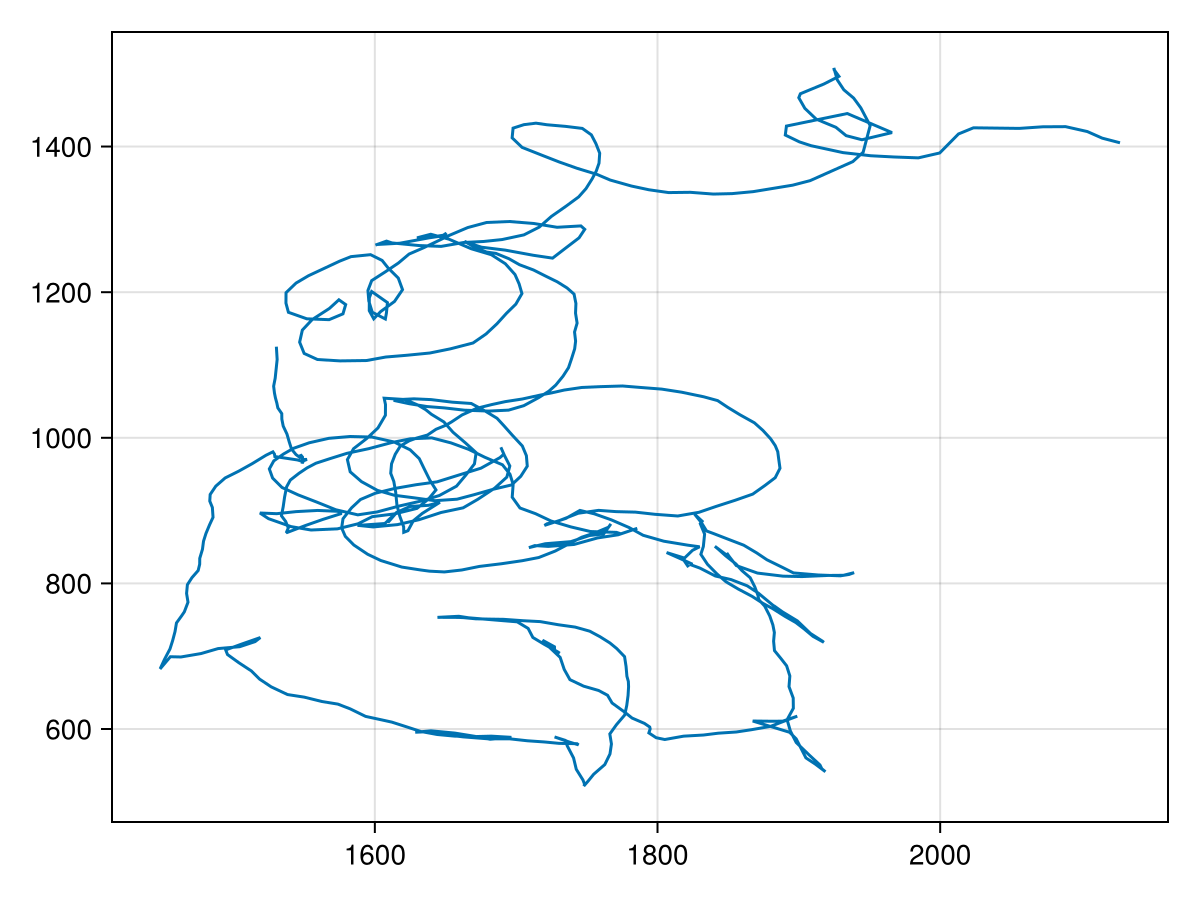

In [481]:
ori_df = read2dfs(subjs[4], p2csvs)[2]
tmp_df = @pipe  ori_df |> 
    filter(:frames => x -> (x >300 &&  x%20==1), _)
    
println("missing frames: ", cal_missing(tmp_df))
lines(tmp_df, [:x, :y])
    

In [181]:
tmp_df |> filter(:frames => ==(11621-20))

Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64


In [185]:
@pipe tmp_df |> sort!(_,:frames)

Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64
1,301,1,1527.14,1084.41,8.47916,17.8936
2,321,1,1527.72,1075.15,6.42993,22.2548
3,341,16,1529.49,1081.82,7.43179,38.7881
4,361,16,1528.39,1070.88,7.84952,25.9948
5,381,16,1528.97,1061.56,9.69524,22.3666
6,401,16,1529.66,1054.81,9.05451,23.113
7,421,16,1530.67,1047.59,10.9304,21.0195
8,441,16,1531.36,1041.09,7.04309,26.1266
9,461,16,1534.14,1033.22,9.09481,19.6391


In [194]:
missing_frames

2-element Vector{Int64}:
 11601
 11901

In [210]:
tmp_df[[i ∈ missing_frames for i in tmp_df.frames], :]

Row,frames,trackers_id,x,y,width,height
,Int64,Int64?,Float64?,Float64?,Float64?,Float64?
1,11601,missing,missing,missing,missing,missing
2,11601,missing,missing,missing,missing,missing
3,11901,missing,missing,missing,missing,missing
4,11901,missing,missing,missing,missing,missing


Row,frames,trackers_id,x,y,width,height
,Int64,Int64?,Float64?,Float64?,Float64?,Float64?
1,301,1,1527.14,1084.41,8.47916,17.8936
2,321,1,1527.72,1075.15,6.42993,22.2548
3,341,16,1529.49,1081.82,7.43179,38.7881
4,361,16,1528.39,1070.88,7.84952,25.9948
5,381,16,1528.97,1061.56,9.69524,22.3666
6,401,16,1529.66,1054.81,9.05451,23.113
7,421,16,1530.67,1047.59,10.9304,21.0195
8,441,16,1531.36,1041.09,7.04309,26.1266
9,461,16,1534.14,1033.22,9.09481,19.6391


In [167]:
missing_df = tmp_df.names

ArgumentError: ArgumentError: column name "names" not found in the data frame; existing most similar names are: "frames"

In [166]:
missing_frames = @pipe tmp_df  |> filter(:diff_frame => x -> !ismissing(x) && x > 20) |> _.frames .- 20

2-element Vector{Int64}:
 11601
 11901

In [142]:
eltype(tmp_df.velocity)

Vector{Union{Missing, Float64}} (alias for Array{Union{Missing, Float64}, 1})

In [213]:
transform!(tmp_df, :frames => (x -> [missing; diff(x)]) => :diff_frame)
[push!(tmp_df,(Dict([i == "frames" ? i => j : i => missing for i in names(tmp_df)]...)), promote=true) for j in missing_frames]
sort!(tmp_df)
transform!(tmp_df, [:x, :y] => ((x,y) -> (@pipe [[missing; diff(x)] [missing;diff(y)]] |> eachrow|> Vector.(_))) => :velocity )
transform!(tmp_df, :velocity => (x -> norm.(x)) => :speed)

Row,frames,trackers_id,x,y,width,height,diff_frame,velocity,speed
,Int64,Int64?,Float64?,Float64?,Float64?,Float64?,Int64?,Array…,Float64?
1,301,1,1527.14,1084.41,8.47916,17.8936,missing,"Union{Missing, Float64}[missing, missing]",missing
2,321,1,1527.72,1075.15,6.42993,22.2548,20,"Union{Missing, Float64}[0.587306, -9.26124]",9.27984
3,341,16,1529.49,1081.82,7.43179,38.7881,20,"Union{Missing, Float64}[1.76327, 6.67413]",6.90313
4,361,16,1528.39,1070.88,7.84952,25.9948,20,"Union{Missing, Float64}[-1.09592, -10.9454]",11.0001
5,381,16,1528.97,1061.56,9.69524,22.3666,20,"Union{Missing, Float64}[0.57484, -9.31604]",9.33376
6,401,16,1529.66,1054.81,9.05451,23.113,20,"Union{Missing, Float64}[0.696928, -6.75529]",6.79115
7,421,16,1530.67,1047.59,10.9304,21.0195,20,"Union{Missing, Float64}[1.00427, -7.22041]",7.28992
8,441,16,1531.36,1041.09,7.04309,26.1266,20,"Union{Missing, Float64}[0.692542, -6.49453]",6.53135
9,461,16,1534.14,1033.22,9.09481,19.6391,20,"Union{Missing, Float64}[2.78452, -7.8742]",8.35204


In [221]:
missing_frames

2-element Vector{Int64}:
 11601
 11901

In [226]:
tmp_df.frames .∈ (missing_frames,)

692-element BitVector:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 ⋮
 0
 0
 0
 0
 0
 0
 0
 0
 0

In [231]:
tmp_df[tmp_df.frames .∈ (missing_frames, ), :]

Row,frames,trackers_id,x,y,width,height,diff_frame,velocity,speed
,Int64,Int64?,Float64?,Float64?,Float64?,Float64?,Int64?,Array…,Float64?
1,11601,missing,missing,missing,missing,missing,missing,"Union{Missing, Float64}[missing, missing]",missing
2,11901,missing,missing,missing,missing,missing,missing,"Union{Missing, Float64}[missing, missing]",missing


In [232]:
@pipe tmp_df |> filter(:speed => x -> ismissing(x == 0) ? false : x==0, _)

Row,frames,trackers_id,x,y,width,height,diff_frame,velocity,speed
,Int64,Int64?,Float64?,Float64?,Float64?,Float64?,Int64?,Array…,Float64?


In [246]:
ori_df = read2dfs(subjs[4], p2csvs)[1] 
for j in missing_frames
    println("last trackers_id: ", tmp_df[tmp_df.frames .== j - 20, :trackers_id][1],  "\tnext trackers_id: ", tmp_df[tmp_df.frames .== j + 20, :trackers_id][1])
end

last trackers_id: 43	next trackers_id: 44
last trackers_id: 50	next trackers_id: 51


In [255]:
ori_df.trackers_id .∈ ([43,44], )

14026-element BitVector:
 0
 0
 0
 0
 0
 0
 0
 0
 0
 0
 ⋮
 0
 0
 0
 0
 0
 0
 0
 0
 0

In [275]:
prev_tracker = @pipe ori_df |> filter(:trackers_id => ==(43)) |> _[end, :]
nex_tracker = @pipe ori_df |> filter(:trackers_id => ==(44)) |> _[1, :]

Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64
1,11618,44,1988.99,1416.01,4.08946,12.7674


In [297]:
(prev_x, prev_y, prev_f) = prev_tracker[[:x, :y,:frames]] |> Vector 
(nex_x, nex_y, nex_f) = nex_tracker[[:x, :y, :frames]] |> Vector 

3-element Vector{Float64}:
  1988.9858156028367
  1416.0141843971628
 11618.0

In [314]:
missing_frames

2-element Vector{Int64}:
 11601
 11901

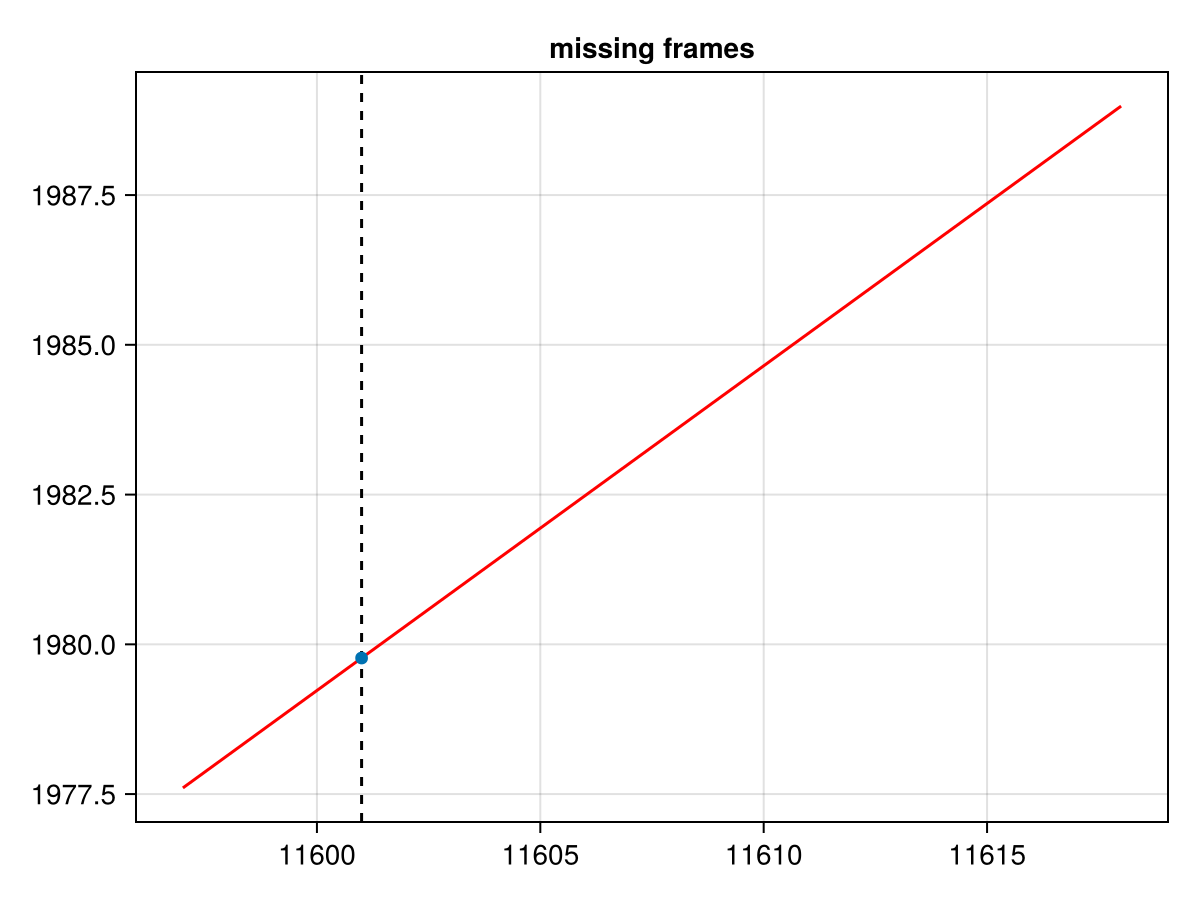

In [317]:
tmp_f = Figure()
ax = Axis(tmp_f[1, 1], title = "missing frames")
lines!(ax,[prev_f, nex_f], [prev_x, nex_x], color = :red)
vlines!(ax, 11601, color=:black, linestyle=:dash)
pred_x = prev_x + (nex_x - prev_x) / (nex_f - prev_f) * (11601 - prev_f)
scatter!(ax, 11601, pred_x)
# lines([prev_f, nex_f], [prev_y, nex_y], color = :red)
tmp_f

In [302]:
norm([prev_x, prev_y] - [nex_x, nex_y]) / abs(prev_f - nex_f)

0.7201709162873753

In [ ]:
function interpolation()
    
end

Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64
1,11618,44,1988.99,1416.01,4.08946,12.7674


Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64
1,11618,44,1988.99,1416.01,4.08946,12.7674


In [238]:
@pipe tmp_df |> filter(:trackers_id => ismissing) |> _.frames

2-element Vector{Int64}:
 11601
 11901

In [234]:
@pipe tmp_df |> transform!(_, [:velocity, :diff_frame] => ByRow((x,y) -> y == 20 ? x : [missing, missing]) )

TypeError: TypeError: non-boolean (Missing) used in boolean context

In [124]:
tmp_df.velocity |> ByRow |> sum

MethodError: MethodError: no method matching iterate(::ByRow{RowSlices{Matrix{Union{Missing, Float64}}, Tuple{Base.OneTo{Int64}}, SubArray{Union{Missing, Float64}, 1, Matrix{Union{Missing, Float64}}, Tuple{Int64, Base.Slice{Base.OneTo{Int64}}}, true}}})
The function `iterate` exists, but no method is defined for this combination of argument types.

Closest candidates are:
  iterate(!Matched::ExponentialBackOff)
   @ Base error.jl:264
  iterate(!Matched::ExponentialBackOff, !Matched::Any)
   @ Base error.jl:264
  iterate(!Matched::Combinatorics.CoolLexCombinations)
   @ Combinatorics ~/.julia/packages/Combinatorics/Udg6X/src/combinations.jl:87
  ...


In [78]:
using LinearAlgebra

In [ ]:
)

$$
\vec{a} \cdot  \vec{b} = \lvert \vec{a} \rvert \cdot \lvert \vec{b} \rvert \cdot \cos \theta
$$

In [88]:
tmp_df[1, :velocity]' *  tmp_df[2, :velocity] / norm(tmp_df[1,:velocity]) * norm(tmp_df[2,:velocity])

missing

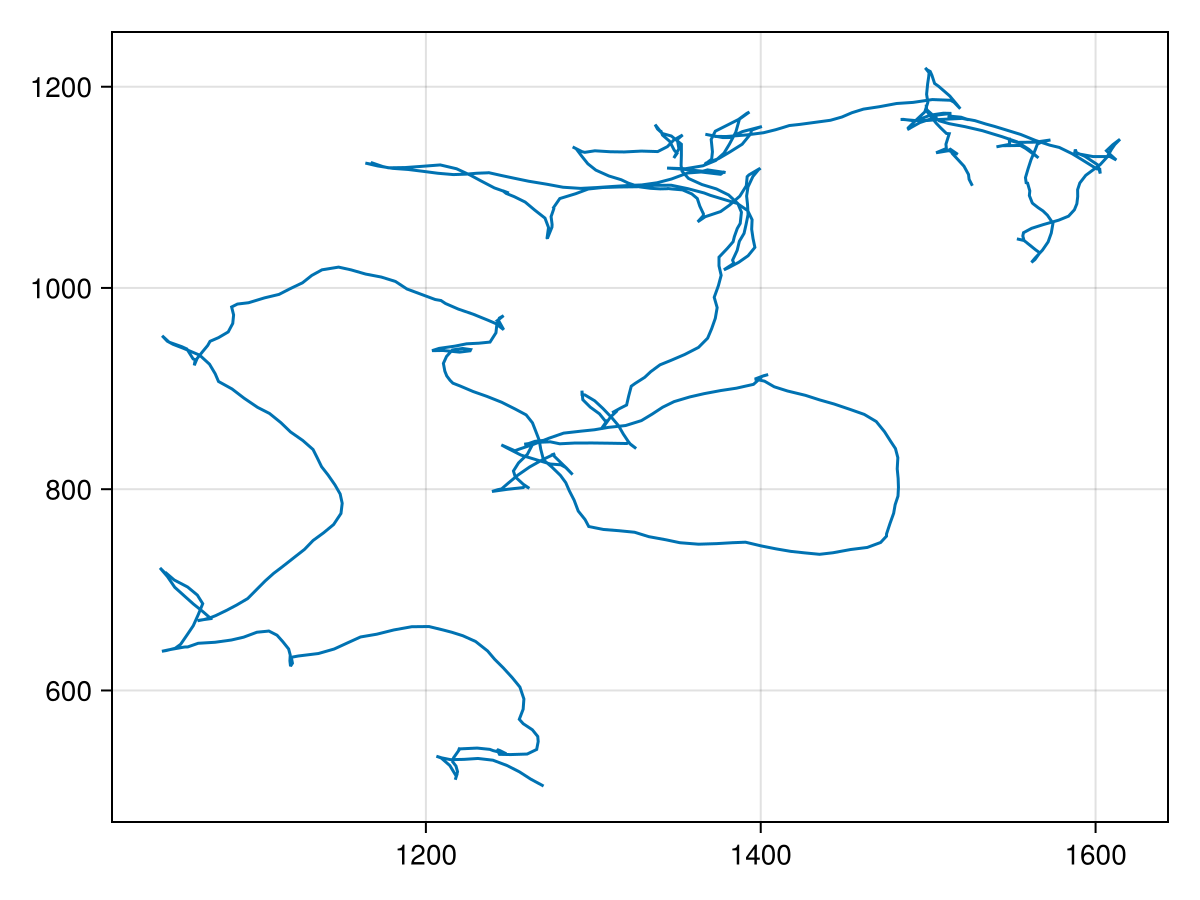

In [15]:
lines(tmp_df, [:x, :y])

In [234]:
# tmp_df = all_csvs[9]
tmp_df[!, :diff_frame] = [0;diff(tmp_df.frames) ]
@pipe tmp_df |> filter(x -> x.diff_frame .> 1, _) |> sort(_,:diff_frame, rev=true)

Row,frames,trackers_id,x,y,width,height,diff_frame
,Int64,Int64,Float64,Float64,Float64,Float64,Int64
1,361,7,1780.03,951.752,4.52926,11.0493,92
2,422,18,1794.41,945.846,6.18954,18.8972,9
3,2959,32,1689.41,1035.58,7.92407,18.1168,2


In [235]:
@pipe tmp_df |> filter(:frames => x -> (x >300 &&  x%20==1), _) |>
     [0; diff(_.frames)] |> filter(x -> x > 20, _)

1-element Vector{Int64}:
 40

10375

In [92]:
tmp_df = all_csvs[2]

@pipe tmp_df |> filter(:frames => x -> x > 280) |>
    _[1:20:end,:] 
    


Row,frames,trackers_id,x,y,width,height
,Int64,Int64,Float64,Float64,Float64,Float64
1,281,3,1528.2,789.071,8.17616,15.2911
2,301,3,1530.21,784.638,6.17922,15.0633
3,321,3,1536.38,780.576,8.49922,12.9396
4,341,3,1540.51,771.278,7.31657,17.0652
5,361,3,1544.8,758.349,5.36311,16.4619
6,381,3,1548.37,746.053,5.96648,18.5202
7,401,3,1558.64,737.123,5.79998,15.9607
8,421,3,1566.07,730.116,6.03163,16.0808
9,441,3,1571.16,716.41,5.98672,17.8513


In [62]:
all((all_csvs[1].frames[2:end] - all_csvs[1].frames[1:end-1]) .== 1)

true

In [37]:
split(subjs[1], "/")[2]

"n2_naive10_3.18"